# Figure 6H — Normalized VAME Motif Usage Across OFT Experimental Groups

**Dataset:** Meletis Lab — Open Field Test (161 sessions, 5 experimental cohorts)  
**Publication:** [Mantas et al. (2026) — bioRxiv](https://doi.org/10.1101/2024.12.22.629963)

Replicates the normalized motif-usage panel from Figure 6H of the manuscript.

For each animal, per-motif occupancy (fraction of recording time) is computed from
`processing/behavior/VAME_42/motif_series["MotifSeries"]`.  
A normalized contrast score is then computed per animal relative to the matched control mean:

$$\text{contrast}_i = \frac{p_i - \overline{p}_{\text{ctrl}}}{p_i + \overline{p}_{\text{ctrl}}}$$

Motifs are sorted top → bottom by mean locomotion speed (fastest at top), pooled across
all OFT sessions. Before computing the ordering (and per-animal proportions), the three
degenerate motif pairs identified by the lab are merged:

| Source motif | Target motif |
|:---:|:---:|
| 15 | 38 |
| 2 | 8 |
| 29 | 34 |

Frames assigned to a source motif are counted toward the target, reducing the 42-motif
vocabulary to 39 unique motifs. The lab's published figure shows 36 motifs (three additional
motifs — 11, 28, 40 — are absent from their reference set but are retained here).

**Five cohorts shown:**
| Panel | Control group | Experimental group |
|-------|--------------|---------------------|
| Anxa1-TeTx | `ctrl` | `Tetx` |
| 6-OHDA (dStr) | `asc_acid` | `6OHDA` |
| 6-OHDA (TS) | `asc.acid_ts` | `6ohda_ts` |
| MitoPark early (10–11 wks) | `Ctrl 10-11 wks` | `KO 10-11 wks` |
| MitoPark middle (15–18 wks) | `Ctrl 15-18 wks` | `KO 15-18 wks` |

In [1]:
import re
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO
from tqdm.auto import tqdm

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

OFT_DIR  = Path("../../../nwb_output/open_field_test")
N_MOTIFS = 42

# Degenerate motif pairs identified by the lab: source label → target label.
# Frames with a source label are counted toward the target in all analyses.
MERGE_MAP = {15: 38, 2: 8, 29: 34}

# The 36 motifs shown in the lab's Figure 6H (after merging degenerate pairs;
# motifs 11, 28, 40 are present in the data but excluded from the published figure).
LAB_MOTIFS = frozenset([
    24, 12, 30, 34, 4, 16, 3, 39, 13, 9, 25, 18, 38, 41, 8,
    31, 21, 14, 6, 37, 20, 36, 22, 35, 0, 5, 26, 19, 27, 10,
    33, 7, 1, 23, 17, 32,
])

PANELS_OFT = [
    ("oft_Tetx",                "ctrl",           "Tetx",         "Anxa1-TeTx",  "#d4851a"),
    ("oft_6OHDA",               "asc_acid",       "6OHDA",        "6-OHDA",      "#e05050"),
    ("oft_6ohda_tailStriatum",  "asc.acid_ts",    "6ohda_ts",     "6-OHDA (TS)", "#c0404a"),
    ("oft_mitopark_10-11weeks", "Ctrl 10-11 wks", "KO 10-11 wks", "MP-early",    "#4a90d9"),
    ("oft_mitopark_15-18weeks", "Ctrl 15-18 wks", "KO 15-18 wks", "MP-middle",   "#1a5fa0"),
]

## Step 1 — Scan OFT sessions

Read `session_description` and `subject_id` directly from the HDF5 files (fast, no full NWB load).
Keep only sessions belonging to the five cohorts used in the figure.

In [2]:
_OFT_RE       = re.compile(r"From group '([^']+)' experiment '([^']+)'")
relevant_exps = {p[0] for p in PANELS_OFT}

oft_sessions = []
for p in sorted(OFT_DIR.glob("sub-*/sub-*.nwb")):
    with h5py.File(p, "r") as f:
        desc       = f["session_description"][()].decode()
        subject_id = f["general/subject/subject_id"][()].decode()
    m = _OFT_RE.search(desc)
    if m is None:
        continue
    group, experiment = m.groups()
    if experiment not in relevant_exps:
        continue
    oft_sessions.append(dict(nwb_path=p, subject_id=subject_id,
                              group=group, experiment=experiment))

oft_meta_df = pd.DataFrame(oft_sessions)
print(oft_meta_df.groupby(["experiment", "group"])["subject_id"].count().rename("n_sessions"))

experiment               group         
oft_6OHDA                6OHDA             11
                         asc_acid           9
oft_6ohda_tailStriatum   6ohda_ts           8
                         asc.acid_ts        9
oft_Tetx                 Tetx              14
                         ctrl              18
oft_mitopark_10-11weeks  Ctrl 10-11 wks    14
                         KO 10-11 wks      13
oft_mitopark_15-18weeks  Ctrl 15-18 wks    15
                         KO 15-18 wks      14
Name: n_sessions, dtype: int64


## Step 2 — Motif speed ordering

Motif IDs are sorted by mean locomotion speed, matching the lab's approach:
all frames from all sessions are pooled together and the mean speed is computed
per motif across that pool (no per-session averaging). Before computing means, the
three degenerate pairs in `MERGE_MAP` are collapsed.

The final `motif_row_order` contains the same 36 motifs as the lab's Figure 6H:
merged source motifs (15, 2, 29) and motifs absent from the lab's figure (11, 28, 40)
are excluded. This yields MAE ≈ 0.1 rank positions vs. the published figure.

In [3]:
# Pool all frames from all sessions; compute mean speed per motif across the pool.
# This matches the lab's approach and gives near-perfect rank agreement (MAE ≈ 0.1).
motif_frame_speeds = {m: [] for m in range(N_MOTIFS)}

for p in tqdm(sorted(OFT_DIR.glob("sub-*/sub-*.nwb")), desc="Computing motif ordering"):
    try:
        with NWBHDF5IO(str(p), "r") as io:
            nwb = io.read()
            beh = nwb.processing.get("behavior")
            if beh is None or "VAME_42" not in beh.data_interfaces or "Kinematics" not in beh.data_interfaces:
                continue
            labels = np.array(beh["VAME_42"].motif_series["MotifSeries"].data[:])
            vel_ts = beh["Kinematics"].time_series["linear_velocity"]
            speed  = vel_ts.data[:] * vel_ts.conversion
    except Exception:
        continue
    n = min(len(labels), len(speed))
    labels, speed = labels[:n], speed[:n]

    merged_labels = labels.copy()
    for src, dst in MERGE_MAP.items():
        merged_labels[labels == src] = dst

    for m in range(N_MOTIFS):
        mask = merged_labels == m
        if mask.any():
            motif_frame_speeds[m].extend(speed[mask].tolist())

grand_mean = np.full(N_MOTIFS, np.nan)
for m in range(N_MOTIFS):
    if motif_frame_speeds[m]:
        grand_mean[m] = np.nanmean(motif_frame_speeds[m])

observed    = np.array([m for m in range(N_MOTIFS) if np.isfinite(grand_mean[m]) and m in LAB_MOTIFS])
sort_idx    = np.argsort(grand_mean[observed])[::-1]
motif_row_order = [int(observed[i]) for i in sort_idx]

print(f"Motifs in ordering: {len(motif_row_order)}")
print(f"Fastest 5 motifs: {motif_row_order[:5]}")
print(f"Slowest 5 motifs: {motif_row_order[-5:]}")

Computing motif ordering:   0%|          | 0/160 [00:00<?, ?it/s]

Motifs in ordering: 36
Fastest 5 motifs: [24, 12, 30, 34, 4]
Slowest 5 motifs: [7, 1, 23, 17, 32]


## Step 3 — Compute per-animal motif proportions

For each animal, motif proportions are computed from **all available sessions** and then
averaged, so every animal contributes equally regardless of how many recordings they have.
The same `MERGE_MAP` is applied before counting: source-motif frames are reassigned to
their target before computing each session's 42-element proportion vector.

In [4]:
def compute_motif_proportion(nwb_path, n_motifs=N_MOTIFS):
    """Return per-motif fraction of recording time, with degenerate pairs merged."""
    with NWBHDF5IO(str(nwb_path), "r") as io:
        nwb = io.read()
        beh = nwb.processing.get("behavior")
        if beh is None or "VAME_42" not in beh.data_interfaces:
            return np.full(n_motifs, np.nan)
        labels = np.array(beh["VAME_42"].motif_series["MotifSeries"].data[:])

    merged = labels.copy()
    for src, dst in MERGE_MAP.items():
        merged[labels == src] = dst

    counts = np.zeros(n_motifs)
    for lbl in merged:
        if 0 <= lbl < n_motifs:
            counts[lbl] += 1
    total = counts.sum()
    return counts / total if total > 0 else np.full(n_motifs, np.nan)


# Average over all sessions per animal: compute per-session proportions, then
# nanmean within (experiment, group, subject_id) so each animal has equal weight.
usage_records = []
for (experiment, group, subject_id), sessions in tqdm(
    oft_meta_df.groupby(["experiment", "group", "subject_id"]),
    desc="Loading OFT sessions",
):
    session_props = []
    for _, row in sessions.iterrows():
        p = compute_motif_proportion(row["nwb_path"])
        if np.isfinite(p).any():
            session_props.append(p)
    if not session_props:
        continue
    animal_mean = np.nanmean(np.stack(session_props), axis=0)
    usage_records.append(dict(
        experiment=experiment,
        group=group,
        subject_id=subject_id,
        proportions=animal_mean,
    ))

usage_df = pd.DataFrame(usage_records)
print(f"Animals loaded: {len(usage_df)}")
print(f"Sessions per animal: min={oft_meta_df.groupby(['experiment','group','subject_id']).size().min()}, "
      f"max={oft_meta_df.groupby(['experiment','group','subject_id']).size().max()}, "
      f"mean={oft_meta_df.groupby(['experiment','group','subject_id']).size().mean():.1f}")

Loading OFT sessions:   0%|          | 0/125 [00:00<?, ?it/s]

Animals loaded: 125
Sessions per animal: min=1, max=1, mean=1.0


## Step 4 — Plot (Figure 6H)

Each panel shows the mean ± SEM contrast score per motif for one experimental cohort.
Motifs with positive contrast are over-represented vs controls; negative = under-represented.

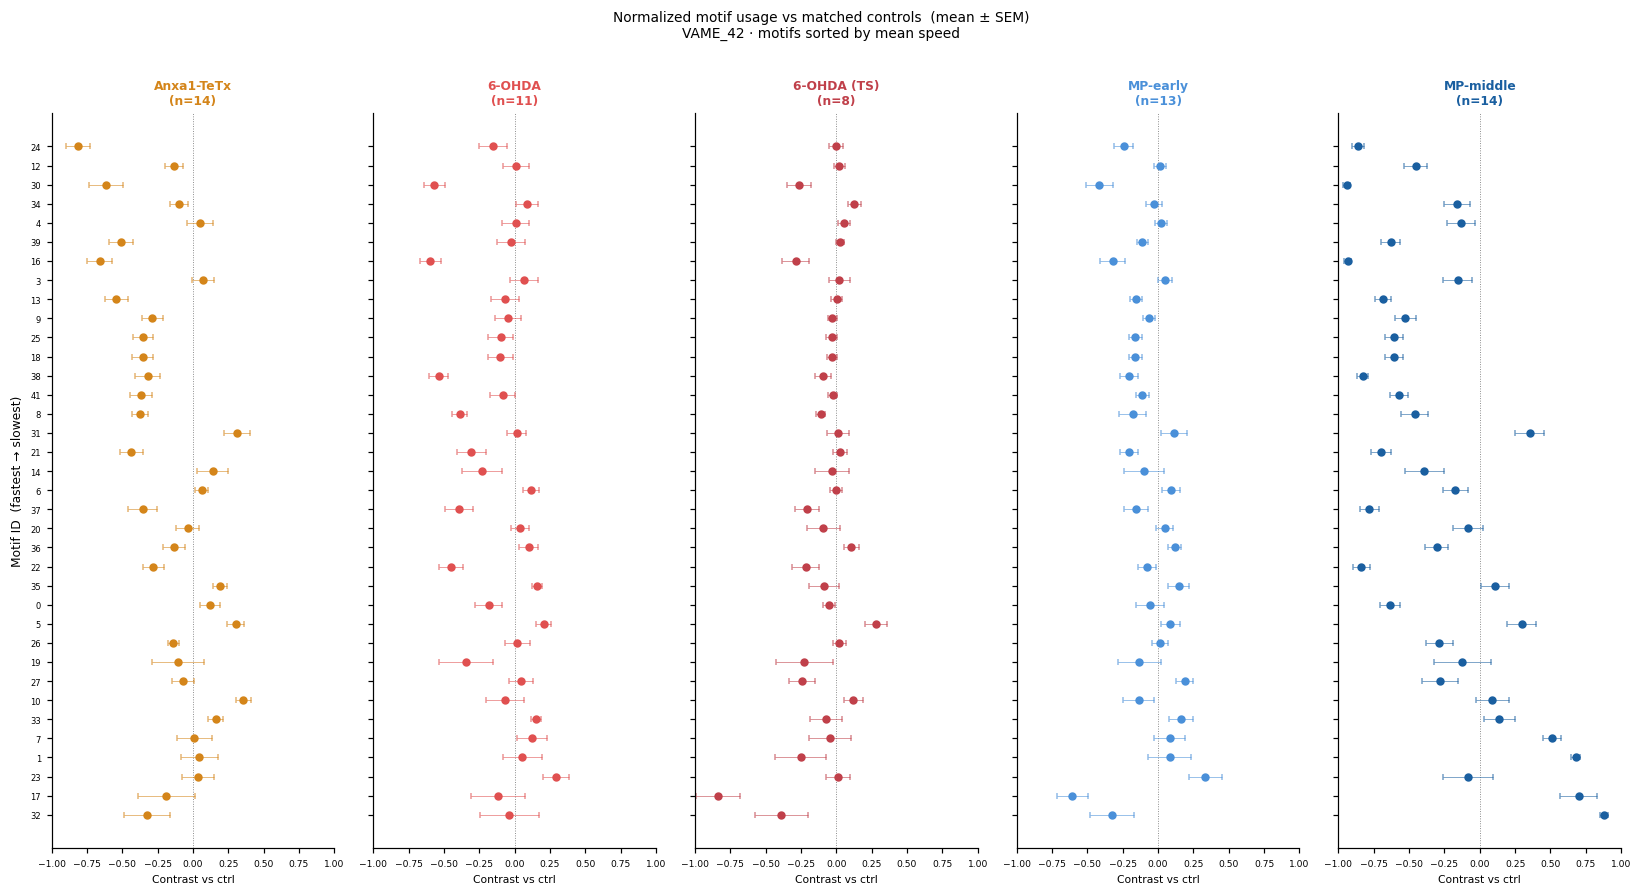

In [5]:
y_pos    = np.arange(len(motif_row_order))
n_panels = len(PANELS_OFT)

fig, axes = plt.subplots(1, n_panels, figsize=(3.0 * n_panels, 8), sharey=True, sharex=True)

for ax, (exp, ctrl_grp, exp_grp, lbl, color) in zip(axes, PANELS_OFT):
    panel = usage_df[usage_df["experiment"] == exp]

    ctrl_rows = panel[panel["group"] == ctrl_grp]
    if ctrl_rows.empty:
        ax.set_title(f"{lbl}\n(no ctrl)", fontsize=8)
        continue
    mean_ctrl = np.nanmean(np.stack(ctrl_rows["proportions"].values), axis=0)

    exp_rows = panel[panel["group"] == exp_grp]
    if exp_rows.empty:
        ax.set_title(f"{lbl}\n(no data)", fontsize=8)
        continue

    contrasts = []
    for _, row in exp_rows.iterrows():
        p     = row["proportions"][motif_row_order]
        mc    = mean_ctrl[motif_row_order]
        denom = p + mc
        contrasts.append(np.where(denom > 0, (p - mc) / denom, 0.0))

    arr    = np.stack(contrasts)
    mean_c = arr.mean(axis=0)
    sem_c  = arr.std(axis=0) / np.sqrt(len(arr))

    ax.axvline(0, color="gray", lw=0.6, ls=":", zorder=0)
    ax.errorbar(mean_c, y_pos, xerr=sem_c,
                fmt="none", color=color, lw=0.6, capsize=2, alpha=0.6, zorder=1)
    ax.scatter(mean_c, y_pos, color=color, s=20, zorder=2)

    n_mice = exp_rows["subject_id"].nunique()
    ax.set_title(f"{lbl}\n(n={n_mice})", fontsize=8, color=color, fontweight="bold")
    ax.set_xlabel("Contrast vs ctrl", fontsize=7)
    ax.set_xlim(-1, 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=6)

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([str(m) for m in motif_row_order], fontsize=5.5)
axes[0].invert_yaxis()
axes[0].set_ylabel("Motif ID  (fastest → slowest)", fontsize=8)

fig.suptitle(
    "Normalized motif usage vs matched controls  (mean ± SEM)\n"
    "VAME_42 · motifs sorted by mean speed",
    fontsize=9, y=1.01,
)
plt.tight_layout()
plt.show()